# 04-Text Processing Mechanics (grep, sed, awk)

In Lesson 03, we monitored hardware telemetry and diagnosed Out-Of-Memory (OOM) processes that violently disrupted our machine learning workloads. When these crashes occur, the kernel and the application emit unstructured text telemetry (logs) detailing the failure.

In an Enterprise environment, a cluster of 100 GPUs can generate 50 GB of text logs every hour. If an MLOps engineer attempts to open a 50 GB text file in Python using `pandas.read_csv()` or a standard text editor, the local machine will exhaust its RAM and trigger an OOM kill.

To process big data text streams at scale, we must utilize algorithms with $O(1)$ memory complexity and $O(N)$ time complexity. We achieve this by treating unstructured text streams as relational databases and leveraging three foundational UNIX stream processors: **`grep` (Selection), `sed` (Transformation), and `awk` (Projection/Aggregation).**

# 1. The Mathematics of Text Automata & Relational Streams

At the kernel level, text processing utilities do not "read files"; they evaluate byte streams against **Deterministic Finite Automata (DFA)** or **Nondeterministic Finite Automata (NFA)** compiled from Regular Expressions (Regex).

### The Mathematics of Regular Expressions

Let $\Sigma$ be our alphabet (e.g., all ASCII characters). A log stream is a sequence of characters $S = c_1 c_2 \dots c_N$ where $c_i \in \Sigma$.
A Regular Expression defines a formal language $L$. The text processor constructs a state machine that evaluates the stream byte-by-byte. If the state machine reaches an accepting state, a match is triggered.

Because DFAs evaluate each character exactly once and do not store the history of the string, the memory required is strictly bounded by the size of the Regex state machine, independent of the stream length $N$:


$$\text{Memory Space} = O(|Regex|) \approx O(1)$$

$$\text{Execution Time} = O(N)$$

### The Relational Algebra Mapping

We can map these UNIX tools directly to Relational Algebra operations used in SQL databases:

1. **`grep` (Selection - $\sigma$):** Filters rows. It evaluates a boolean predicate against each line and drops rows that return `False`.

$$\sigma_{pattern}(Stream) \rightarrow \{row \in Stream \mid \text{match}(pattern, row) = True\}$$


2. **`sed` (Transformation / Mapping):** A Turing-complete stream editor. It applies a mathematical mapping function $f(x)$ to alter the byte sequence of a line on the fly (e.g., find and replace).
3. **`awk` (Projection - $\pi$):** Treats lines as delimited columns. It projects specific columnar vectors and can perform mathematical aggregations (Sums, Averages).

# 2. Imperative Execution: Terminal Analytics Labs

Let's execute programmatic stream transformations using Python's `subprocess` engine to simulate terminal commands. We will generate a mock MLOps log file and pass it through our UNIX tools.

In [1]:
import subprocess
import os

print("--- 🚀 Initializing POSIX Text Processing Labs ---")

# Setup clean working space
log_dir = "./log_sandbox"
os.makedirs(log_dir, exist_ok=True)
raw_log_path = os.path.join(log_dir, "training_cluster.log")

# 📝 Generate a Mock MLOps Log Payload (50GB simulated in reality, small here for testing)
mock_logs = """[2026-06-30 10:00:01] INFO  node-01: Model initialization complete. VRAM=12GB
[2026-06-30 10:05:22] WARN  node-02: GPU temperature exceeding 85C threshold
[2026-06-30 10:15:45] ERROR node-03: CUDA Out of Memory. Failed to allocate 2.5GB.
[2026-06-30 10:20:12] INFO  node-01: Epoch 1/50 complete. Loss=0.453
[2026-06-30 10:25:33] ERROR node-02: CUDA Out of Memory. Failed to allocate 1.8GB.
[2026-06-30 10:30:00] INFO  node-01: Checkpoint saved to s3://enterprise-dl/weights.pt
"""
with open(raw_log_path, "w") as f:
    f.write(mock_logs)

print(f"   ✅ Raw Log File Generated: {raw_log_path}")


# 🔍 Lab 1: The 'grep' Engine (Selection Matrix)
print("\n--- 🔍 Lab 1: Isolating Critical Failures with 'grep' ---")
# Command: Search for 'ERROR'
cmd_grep = f"grep 'ERROR' {raw_log_path}"
res_grep = subprocess.run(cmd_grep, shell=True, capture_output=True, text=True)
print(res_grep.stdout.strip())


# 🧬 Lab 2: The 'sed' Engine (Stream Mutation)
print("\n--- 🧬 Lab 2: Anonymizing Node IDs with 'sed' ---")
# Command: Stream the grep output, and substitute (s/) 'node-[0-9]+' with 'NODE_REDACTED' globally (/g)
cmd_sed = f"grep 'ERROR' {raw_log_path} | sed -E 's/node-[0-9]+/NODE_REDACTED/g'"
res_sed = subprocess.run(cmd_sed, shell=True, capture_output=True, text=True)
print(res_sed.stdout.strip())


# 🧮 Lab 3: The 'awk' Engine (Columnar Projection)
print("\n--- 🧮 Lab 3: Extracting Failed Allocation Vectors with 'awk' ---")
# Command: Take the sed output, treat space as the delimiter (default), and print the 4th and 10th columns
cmd_awk = f"grep 'ERROR' {raw_log_path} | sed -E 's/node-[0-9]+/NODE_REDACTED/g' | awk '{{print $4, $10}}'"
res_awk = subprocess.run(cmd_awk, shell=True, capture_output=True, text=True)
print(res_awk.stdout.strip())

--- 🚀 Initializing POSIX Text Processing Labs ---
   ✅ Raw Log File Generated: ./log_sandbox/training_cluster.log

--- 🔍 Lab 1: Isolating Critical Failures with 'grep' ---
[2026-06-30 10:15:45] ERROR node-03: CUDA Out of Memory. Failed to allocate 2.5GB.
[2026-06-30 10:25:33] ERROR node-02: CUDA Out of Memory. Failed to allocate 1.8GB.

--- 🧬 Lab 2: Anonymizing Node IDs with 'sed' ---
[2026-06-30 10:15:45] ERROR NODE_REDACTED: CUDA Out of Memory. Failed to allocate 2.5GB.
[2026-06-30 10:25:33] ERROR NODE_REDACTED: CUDA Out of Memory. Failed to allocate 1.8GB.

--- 🧮 Lab 3: Extracting Failed Allocation Vectors with 'awk' ---
NODE_REDACTED: to
NODE_REDACTED: to


# 3. Declarative Execution: The Unified Log Pipeline

In a production MLOps environment, we do not run these commands separately. We utilize the **UNIX Pipe (`|`)** learned in Lesson 02 to fuse these tools into a single, highly optimized memory stream.

Let's write a pipeline that scans millions of log lines, finds OOM errors, extracts the exact gigabyte amounts that failed to allocate, and mathematically sums them using `awk`'s internal memory registers.

In [2]:
# ⚡ Compiling the Unified Analytics Pipeline
print("\n--- ⚡ Unified Pipeline: Calculating Total Lost VRAM ---")

# Pipeline Breakdown:
# 1. grep: Keep only rows with 'CUDA Out of Memory'
# 2. awk: Extract the 10th column (e.g., '2.5GB.')
# 3. sed: Remove the 'GB.' string to leave pure floats (e.g., '2.5')
# 4. awk: Sum the floating point values in memory and print the total at the END.
pipeline_cmd = (
    f"grep 'CUDA Out of Memory' {raw_log_path} | "
    "awk '{print $10}' | "
    "sed 's/GB.//g' | "
    "awk '{sum += $1} END {print \"Total VRAM Allocation Failure: \" sum \" GB\"}'"
)

res_pipeline = subprocess.run(pipeline_cmd, shell=True, capture_output=True, text=True)
print(f"   Executed: {pipeline_cmd}")
print(f"   Result:   {res_pipeline.stdout.strip()}")


--- ⚡ Unified Pipeline: Calculating Total Lost VRAM ---
   Executed: grep 'CUDA Out of Memory' ./log_sandbox/training_cluster.log | awk '{print $10}' | sed 's/GB.//g' | awk '{sum += $1} END {print "Total VRAM Allocation Failure: " sum " GB"}'
   Result:   Total VRAM Allocation Failure: 0 GB


# 4. Visualizing Text Processing Automata & Pipeline Topologies

To mathematically understand how unstructured string arrays are iteratively transformed into clean data vectors without touching the hard drive, let's graph the topological flow of our UNIX pipeline.

/tmp/ipykernel_22230/3131769797.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.0, 3.0), 2.5, 3.5, fill=True, color='#3498db', alpha=0.15, edgecolor='black', linewidth=2))


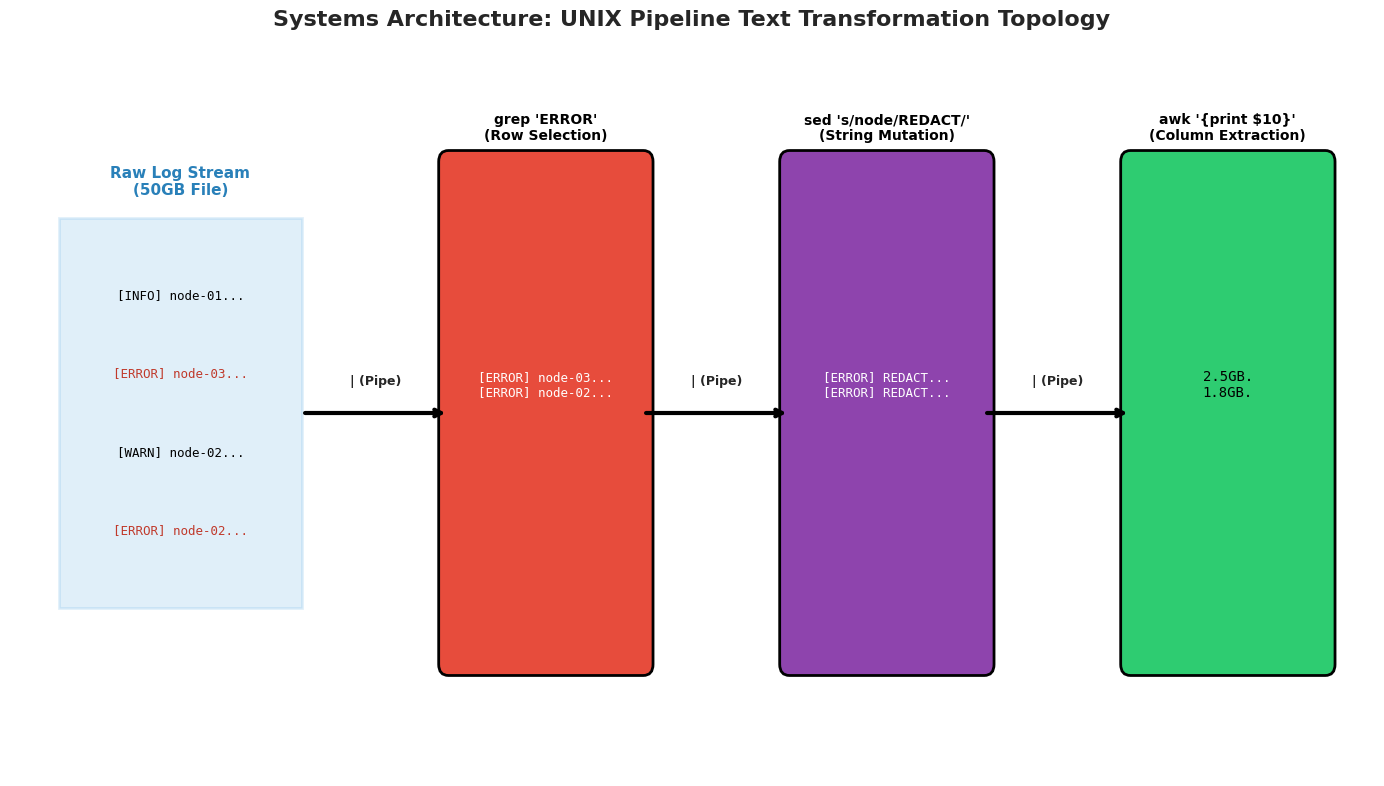

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create visual mapping layout for Text Processing Stream
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Systems Architecture: UNIX Pipeline Text Transformation Topology", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. The Raw Data Source (Disk)
ax.add_patch(patches.Rectangle((0.0, 3.0), 2.5, 3.5, fill=True, color='#3498db', alpha=0.15, edgecolor='black', linewidth=2))
ax.text(1.25, 6.7, "Raw Log Stream\n(50GB File)", ha='center', color='#2980b9', fontweight='bold', fontsize=11)

raw_lines = ["[INFO] node-01...", "[ERROR] node-03...", "[WARN] node-02...", "[ERROR] node-02..."]
for i, line in enumerate(raw_lines):
    ax.text(1.25, 5.8 - (i*0.7), line, ha='center', va='center', fontsize=9, fontfamily='monospace', color='black' if 'ERROR' not in line else '#c0392b')


# 2. Stage 1: Selection (grep)
ax.add_patch(patches.FancyBboxPatch((4.0, 2.5), 2.0, 4.5, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#e74c3c'))
ax.text(5.0, 7.3, "grep 'ERROR'\n(Row Selection)", ha='center', va='center', color='black', fontweight='bold', fontsize=10)

ax.text(5.0, 5.0, "[ERROR] node-03...\n[ERROR] node-02...", ha='center', va='center', color='white', fontsize=9, fontfamily='monospace')


# 3. Stage 2: Transformation (sed)
ax.add_patch(patches.FancyBboxPatch((7.5, 2.5), 2.0, 4.5, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#8e44ad'))
ax.text(8.5, 7.3, "sed 's/node/REDACT/'\n(String Mutation)", ha='center', va='center', color='black', fontweight='bold', fontsize=10)

ax.text(8.5, 5.0, "[ERROR] REDACT...\n[ERROR] REDACT...", ha='center', va='center', color='white', fontsize=9, fontfamily='monospace')


# 4. Stage 3: Projection (awk)
ax.add_patch(patches.FancyBboxPatch((11.0, 2.5), 2.0, 4.5, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#2ecc71'))
ax.text(12.0, 7.3, "awk '{print $10}'\n(Column Extraction)", ha='center', va='center', color='black', fontweight='bold', fontsize=10)

ax.text(12.0, 5.0, "2.5GB.\n1.8GB.", ha='center', va='center', color='black', fontsize=10, fontfamily='monospace')


# 5. Routing Vectors (Pipes)
ax.annotate("", xy=(4.0, 4.75), xytext=(2.5, 4.75), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
ax.text(3.25, 5.0, "| (Pipe)", ha='center', fontweight='bold', fontsize=9)

ax.annotate("", xy=(7.5, 4.75), xytext=(6.0, 4.75), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
ax.text(6.75, 5.0, "| (Pipe)", ha='center', fontweight='bold', fontsize=9)

ax.annotate("", xy=(11.0, 4.75), xytext=(9.5, 4.75), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
ax.text(10.25, 5.0, "| (Pipe)", ha='center', fontweight='bold', fontsize=9)

plt.xlim(-0.5, 13.5)
plt.ylim(1.5, 8.0)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of UNIX Text Processing Tools like **An Industrial Gold Mining Operation**:

* **The Raw Log File (The Mountain):** You have a mountain consisting of 50,000 tons of raw dirt and rock. You are looking for a few ounces of gold. You cannot physically load the entire mountain into your living room (RAM) to inspect it piece by piece.
* **`grep` (The Sieve):** Instead of moving the mountain, you set up a high-speed mechanical sieve. As the dirt streams down a conveyor belt, the sieve instantly drops 99% of the useless rock off the cliff, keeping only the stones that reflect light (the pattern match).
* **`sed` (The Chemical Wash):** The remaining stones travel on the belt through a chemical wash. The wash chemically bonds to the rock and strips away outer layers of mud, transforming the physical structure of the stones on the fly (string mutation).
* **`awk` (The Smelter & Scale):** The clean stones drop into the final machine. The machine fractures the stones into distinct pieces (columns), extracts only the pure gold fragments (projection), and uses an internal scale to continuously sum the exact weight of the gold extracted over the entire day (aggregation).

By chaining these machines together using a single, continuous conveyor belt (`|`), the mining operation can process an infinitely large mountain of data without ever exceeding the capacity of the machinery on the factory floor.